In [2]:
  cd ../..

/home/sangonvi/Cefet/repositories/rionowcastdf


In [3]:
# =============================================================================
# Notebook 05
# Extreme Events Analysis
# =============================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("ggplot")

OUTPUT = Path("datasets/radar_statistics")
FIGURES = OUTPUT / "figures"

FIGURES.mkdir(
    exist_ok=True,
    parents=True,
)

df = pd.read_parquet(
    OUTPUT / "summary.parquet"
)

df["timestamp"] = pd.to_datetime(df["timestamp"])

print(df.head())

            timestamp  rain_pixels  rain_fraction       mean       std  \
0 2011-01-17 15:36:00          184       0.031293  31.663322  8.129971   
1 2011-01-17 15:44:00          207       0.035204  29.805325  7.576298   
2 2011-01-17 15:46:00          213       0.036224  29.541319  7.312479   
3 2011-01-17 15:48:00          197       0.033503  29.265385  7.915115   
4 2011-01-17 15:50:00          192       0.032653  29.176849  7.859232   

   maximum       volume        p50   p90        p95   p99  
0     45.0  5826.051270  30.000000  40.0  45.000000  45.0  
1     45.0  6169.702148  30.000000  40.0  43.898239  45.0  
2     45.0  6292.300781  30.000000  40.0  45.000000  45.0  
3     45.0  5765.280762  30.000000  40.0  44.441284  45.0  
4     45.0  5601.955078  28.380985  40.0  43.221180  45.0  


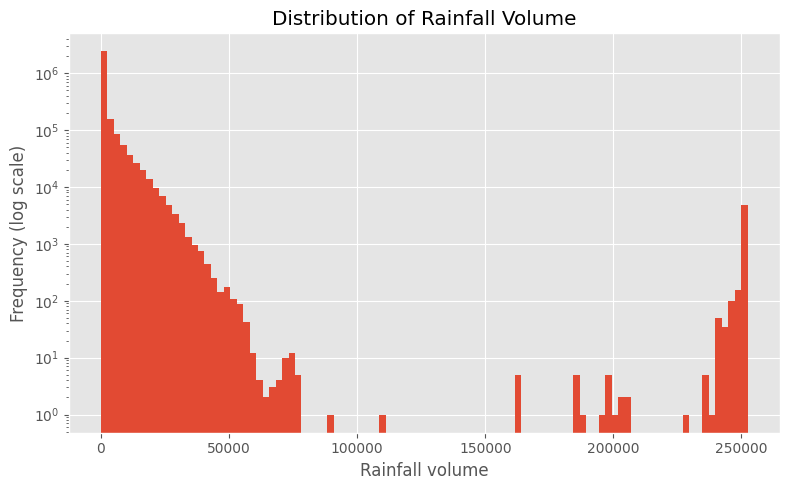

In [4]:
# =============================================================================
# Figure 1
# Rainfall volume distribution
# =============================================================================

plt.figure(figsize=(8,5))

plt.hist(
    df.volume,
    bins=100,
    log=True
)

plt.xlabel("Rainfall volume")

plt.ylabel("Frequency (log scale)")

plt.title("Distribution of Rainfall Volume")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure21_volume_histogram.png",
    dpi=300
)

plt.show()

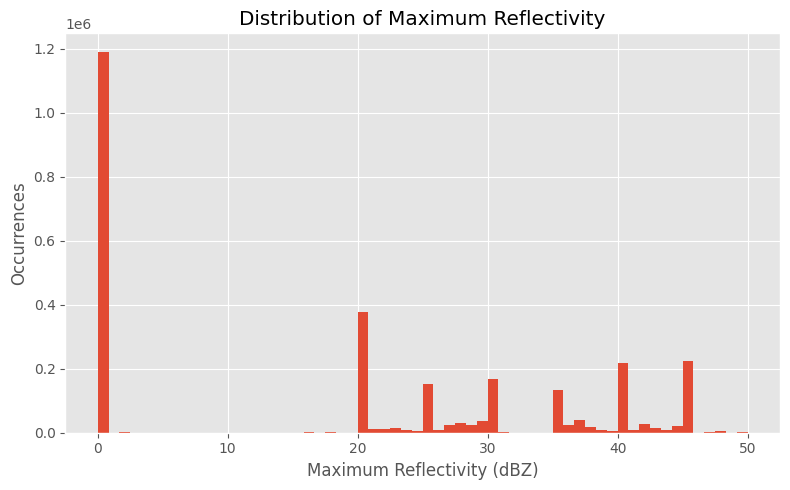

In [5]:
# =============================================================================
# Figure 2
# Maximum reflectivity
# =============================================================================

plt.figure(figsize=(8,5))

plt.hist(
    df.maximum,
    bins=60
)

plt.xlabel("Maximum Reflectivity (dBZ)")

plt.ylabel("Occurrences")

plt.title("Distribution of Maximum Reflectivity")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure22_maximum_histogram.png",
    dpi=300
)

plt.show()

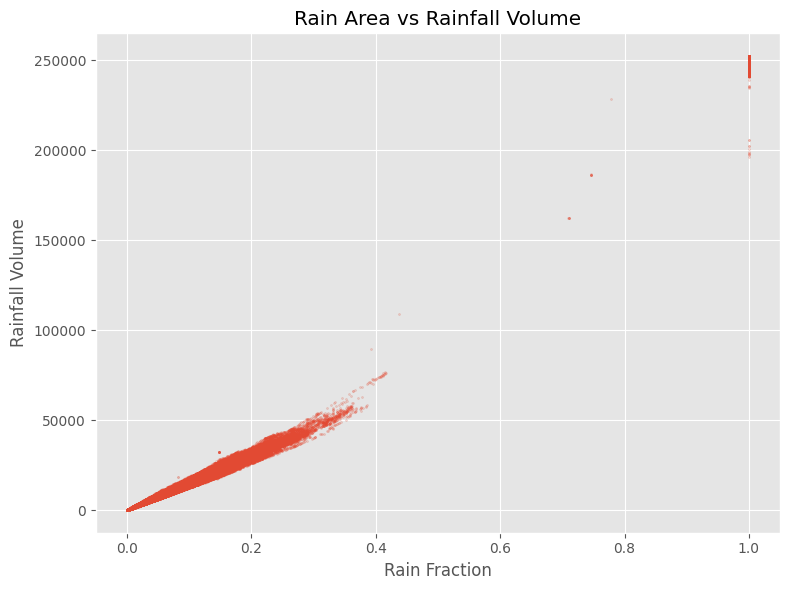

In [6]:
# =============================================================================
# Figure 3
# Rain fraction vs rainfall volume
# =============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df.rain_fraction,
    df.volume,
    s=2,
    alpha=0.2
)

plt.xlabel("Rain Fraction")

plt.ylabel("Rainfall Volume")

plt.title("Rain Area vs Rainfall Volume")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure23_area_vs_volume.png",
    dpi=300
)

plt.show()

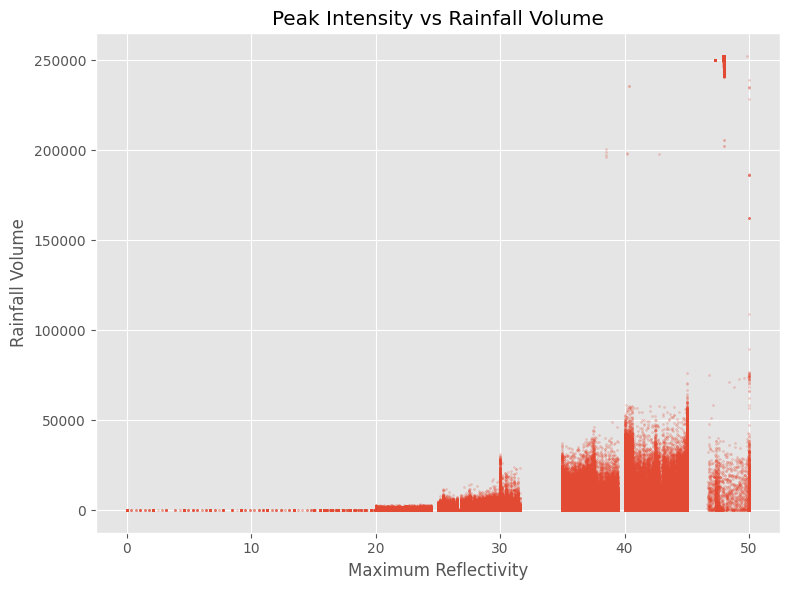

In [7]:
# =============================================================================
# Figure 4
# Peak intensity vs rainfall volume
# =============================================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df.maximum,
    df.volume,
    s=2,
    alpha=0.2
)

plt.xlabel("Maximum Reflectivity")

plt.ylabel("Rainfall Volume")

plt.title("Peak Intensity vs Rainfall Volume")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure24_peak_vs_volume.png",
    dpi=300
)

plt.show()

In [8]:
# =============================================================================
# Rainfall statistics
# =============================================================================

variables = [
    "mean",
    "maximum",
    "volume",
    "rain_fraction",
]

percentiles = [50,75,90,95,99,99.5,99.9]

table = pd.DataFrame()

for var in variables:

    table[var] = np.percentile(
        df[var],
        percentiles
    )

table.index = [
    f"P{p}"
    for p in percentiles
]

table

,mean,maximum,volume,rain_fraction
P50,20.000000,20.000000,40.000000,0.000340
P75,23.442876,35.000000,909.060440,0.006803
P90,26.438823,42.411144,4853.077979,0.033503
P95,28.101202,45.000000,9641.067480,0.065816
P99,31.716856,45.000000,22295.629004,0.146088
P99.5,36.044938,45.000000,28386.763594,0.185034
P99.9,42.926935,47.938271,252398.468750,1.000000


In [9]:
# =============================================================================
# Top rainfall events
# =============================================================================

top = df.sort_values(
    "volume",
    ascending=False
).head(100)

top

,timestamp,rain_pixels,rain_fraction,mean,std,maximum,volume,p50,p90,p95,p99
2763811,2024-05-15 07:16:00,5880,1.0,42.930183,3.518508,47.938271,252429.46875,40.420029,46.781578,46.781578,47.038036
2763810,2024-05-15 07:14:00,5880,1.0,42.930183,3.518508,47.938271,252429.46875,40.420029,46.781578,46.781578,47.038036
74705,2011-09-08 10:20:00,5880,1.0,42.929523,3.518695,47.938271,252425.59375,40.397076,46.781578,46.781578,47.038036
2763901,2024-05-15 10:16:00,5880,1.0,42.929462,3.518747,47.938271,252425.25000,40.397076,46.781578,46.781578,47.038036
2763904,2024-05-15 10:22:00,5880,1.0,42.929462,3.518747,47.938271,252425.25000,40.397076,46.781578,46.781578,47.038036
...,...,...,...,...,...,...,...,...,...,...,...
2763839,2024-05-15 08:12:00,5880,1.0,42.929462,3.518747,47.938271,252425.25000,40.397076,46.781578,46.781578,47.038036
74821,2011-09-08 14:14:00,5880,1.0,42.929462,3.518747,47.938271,252425.25000,40.397076,46.781578,46.781578,47.038036
74822,2011-09-08 14:16:00,5880,1.0,42.929462,3.518747,47.938271,252425.25000,40.397076,46.781578,46.781578,47.038036
74823,2011-09-08 14:18:00,5880,1.0,42.929462,3.518747,47.938271,252425.25000,40.397076,46.781578,46.781578,47.038036


/tmp/ipykernel_9642/454849884.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  events["year"] = events.timestamp.dt.year


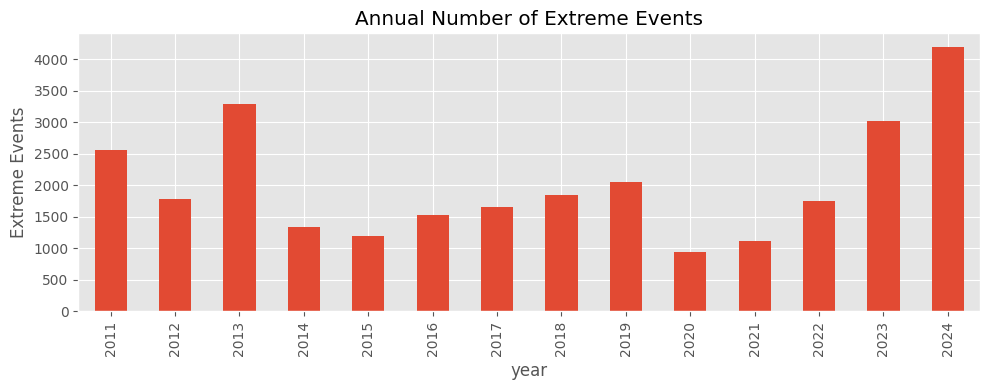

In [10]:
# =============================================================================
# Number of extreme events per year
# =============================================================================

threshold = df.volume.quantile(0.99)

events = df[
    df.volume >= threshold
]

events["year"] = events.timestamp.dt.year

annual = events.groupby("year").size()

plt.figure(figsize=(10,4))

annual.plot.bar()

plt.ylabel("Extreme Events")

plt.title("Annual Number of Extreme Events")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure25_events_per_year.png",
    dpi=300
)

plt.show()

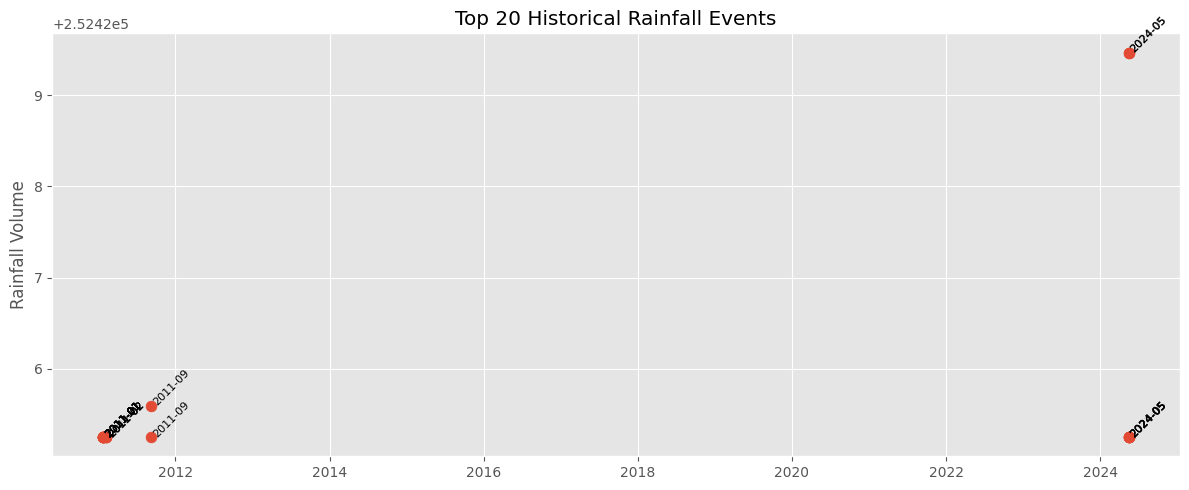

In [11]:
# =============================================================================
# Timeline of the Top-20 Events
# =============================================================================

top20 = df.sort_values(
    "volume",
    ascending=False
).head(20)

plt.figure(figsize=(12,5))

plt.scatter(
    top20.timestamp,
    top20.volume,
    s=60
)

for _, row in top20.iterrows():

    plt.text(
        row.timestamp,
        row.volume,
        row.timestamp.strftime("%Y-%m"),
        fontsize=8,
        rotation=45
    )

plt.ylabel("Rainfall Volume")

plt.title("Top 20 Historical Rainfall Events")

plt.tight_layout()

plt.savefig(
    FIGURES/"figure26_top20_events.png",
    dpi=300
)

plt.show()